In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [87]:
heart_df = pd.read_csv(
    'heart_disease.csv'
)

print(heart_df.head())


    Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0  34.0  0.0            0.0      135.0        134.0        0.0         2.0   
1  61.0  0.0            1.0      157.0        349.0        1.0         0.0   
2  40.0  1.0            0.0      164.0        144.0        1.0         2.0   
3  25.0  0.0            2.0       93.0        285.0        1.0         0.0   
4  74.0  0.0            0.0      143.0        262.0        0.0         0.0   

   MaxHeartRate  ExerciseAngina  Oldpeak  ...  Smoking  Alcohol  \
0         101.0             0.0     4.84  ...      0.0      0.0   
1          62.0             1.0     3.44  ...      0.0      1.0   
2         128.0             1.0     2.92  ...      1.0      0.0   
3          82.0             1.0     5.81  ...      1.0      1.0   
4         138.0             1.0     3.72  ...      0.0      1.0   

   PhysicalActivity  StressLevel  SleepHours  FamilyHistory  Glucose  \
0               2.0         10.0         6.0            

In [88]:
print(heart_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1960 non-null   float64
 1   Sex               1960 non-null   float64
 2   ChestPainType     1960 non-null   float64
 3   RestingBP         1960 non-null   float64
 4   Cholesterol       1960 non-null   float64
 5   FastingBS         1960 non-null   float64
 6   RestingECG        1960 non-null   float64
 7   MaxHeartRate      1960 non-null   float64
 8   ExerciseAngina    1960 non-null   float64
 9   Oldpeak           1960 non-null   float64
 10  Slope             1960 non-null   float64
 11  MajorVessels      1960 non-null   float64
 12  Thal              1960 non-null   float64
 13  Weight            1960 non-null   float64
 14  Height            1960 non-null   float64
 15  BMI               1960 non-null   float64
 16  Smoking           1960 non-null   float64
 17  Alcoho

In [89]:
print(heart_df.isnull().sum())

Age                 40
Sex                 40
ChestPainType       40
RestingBP           40
Cholesterol         40
FastingBS           40
RestingECG          40
MaxHeartRate        40
ExerciseAngina      40
Oldpeak             40
Slope               40
MajorVessels        40
Thal                40
Weight              40
Height              40
BMI                 40
Smoking             40
Alcohol             40
PhysicalActivity    40
StressLevel         40
SleepHours          40
FamilyHistory       40
Glucose             40
OxygenLevel         40
HeartRate           40
HeartDisease        40
dtype: int64


In [90]:
removed_df = heart_df.dropna()

print(removed_df.shape)

(1188, 26)


In [91]:
mean_df = heart_df.copy()

mean_df = mean_df.fillna(
    mean_df.mean(numeric_only=True)
)

print(mean_df.head())

    Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0  34.0  0.0            0.0      135.0        134.0        0.0         2.0   
1  61.0  0.0            1.0      157.0        349.0        1.0         0.0   
2  40.0  1.0            0.0      164.0        144.0        1.0         2.0   
3  25.0  0.0            2.0       93.0        285.0        1.0         0.0   
4  74.0  0.0            0.0      143.0        262.0        0.0         0.0   

   MaxHeartRate  ExerciseAngina  Oldpeak  ...  Smoking  Alcohol  \
0         101.0             0.0     4.84  ...      0.0      0.0   
1          62.0             1.0     3.44  ...      0.0      1.0   
2         128.0             1.0     2.92  ...      1.0      0.0   
3          82.0             1.0     5.81  ...      1.0      1.0   
4         138.0             1.0     3.72  ...      0.0      1.0   

   PhysicalActivity  StressLevel  SleepHours  FamilyHistory  Glucose  \
0               2.0         10.0         6.0            

In [92]:
median_df = heart_df.copy()

for col in median_df.columns:

    median_df[col] = median_df[col].fillna(
        median_df[col].median()
    )
print(median_df.head())

    Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0  34.0  0.0            0.0      135.0        134.0        0.0         2.0   
1  61.0  0.0            1.0      157.0        349.0        1.0         0.0   
2  40.0  1.0            0.0      164.0        144.0        1.0         2.0   
3  25.0  0.0            2.0       93.0        285.0        1.0         0.0   
4  74.0  0.0            0.0      143.0        262.0        0.0         0.0   

   MaxHeartRate  ExerciseAngina  Oldpeak  ...  Smoking  Alcohol  \
0         101.0             0.0     4.84  ...      0.0      0.0   
1          62.0             1.0     3.44  ...      0.0      1.0   
2         128.0             1.0     2.92  ...      1.0      0.0   
3          82.0             1.0     5.81  ...      1.0      1.0   
4         138.0             1.0     3.72  ...      0.0      1.0   

   PhysicalActivity  StressLevel  SleepHours  FamilyHistory  Glucose  \
0               2.0         10.0         6.0            

In [93]:
mode_df = heart_df.copy()

for col in mode_df.columns:

    mode_df[col] = mode_df[col].fillna(
        mode_df[col].mode()[0]
    )
print(mode_df.head())

    Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0  34.0  0.0            0.0      135.0        134.0        0.0         2.0   
1  61.0  0.0            1.0      157.0        349.0        1.0         0.0   
2  40.0  1.0            0.0      164.0        144.0        1.0         2.0   
3  25.0  0.0            2.0       93.0        285.0        1.0         0.0   
4  74.0  0.0            0.0      143.0        262.0        0.0         0.0   

   MaxHeartRate  ExerciseAngina  Oldpeak  ...  Smoking  Alcohol  \
0         101.0             0.0     4.84  ...      0.0      0.0   
1          62.0             1.0     3.44  ...      0.0      1.0   
2         128.0             1.0     2.92  ...      1.0      0.0   
3          82.0             1.0     5.81  ...      1.0      1.0   
4         138.0             1.0     3.72  ...      0.0      1.0   

   PhysicalActivity  StressLevel  SleepHours  FamilyHistory  Glucose  \
0               2.0         10.0         6.0            

In [94]:
print(heart_df.duplicated().sum())

heart_df = heart_df.drop_duplicates()

0


In [95]:
clean_df = mean_df.copy()

print(clean_df.isnull().sum())

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol         0
FastingBS           0
RestingECG          0
MaxHeartRate        0
ExerciseAngina      0
Oldpeak             0
Slope               0
MajorVessels        0
Thal                0
Weight              0
Height              0
BMI                 0
Smoking             0
Alcohol             0
PhysicalActivity    0
StressLevel         0
SleepHours          0
FamilyHistory       0
Glucose             0
OxygenLevel         0
HeartRate           0
HeartDisease        0
dtype: int64


In [96]:
Q1 = clean_df.quantile(0.25)

Q3 = clean_df.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (clean_df < (Q1 - 1.5 * IQR)) |
    (clean_df > (Q3 + 1.5 * IQR))
)

print(outliers.sum())

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol         0
FastingBS           0
RestingECG          0
MaxHeartRate        0
ExerciseAngina      0
Oldpeak             0
Slope               0
MajorVessels        0
Thal                0
Weight              0
Height              0
BMI                 5
Smoking             0
Alcohol             0
PhysicalActivity    0
StressLevel         0
SleepHours          0
FamilyHistory       0
Glucose             0
OxygenLevel         0
HeartRate           0
HeartDisease        0
dtype: int64


In [97]:
clean_df = clean_df[
    ~(
        (
            clean_df < (Q1 - 1.5 * IQR)
        ) |
        (
            clean_df > (Q3 + 1.5 * IQR)
        )
    ).any(axis=1)
]

print(clean_df.shape)

(1995, 26)


In [98]:
print(clean_df.describe())

               Age          Sex  ChestPainType    RestingBP  Cholesterol  \
count  1995.000000  1995.000000    1995.000000  1995.000000  1995.000000   
mean     52.046627     0.516618       1.522705   134.092947   237.834474   
std      15.600785     0.494812       1.113818    25.950956    65.580274   
min      25.000000     0.000000       0.000000    90.000000   120.000000   
25%      39.000000     0.000000       1.000000   112.000000   180.000000   
50%      52.000510     1.000000       1.519898   134.135714   238.000000   
75%      65.000000     1.000000       3.000000   157.000000   293.000000   
max      79.000000     1.000000       3.000000   179.000000   349.000000   

         FastingBS   RestingECG  MaxHeartRate  ExerciseAngina      Oldpeak  \
count  1995.000000  1995.000000   1995.000000     1995.000000  1995.000000   
mean      0.506409     0.979050    135.643077        0.503831     3.026338   
std       0.495046     0.808723     42.313023        0.495072     1.717384   
min

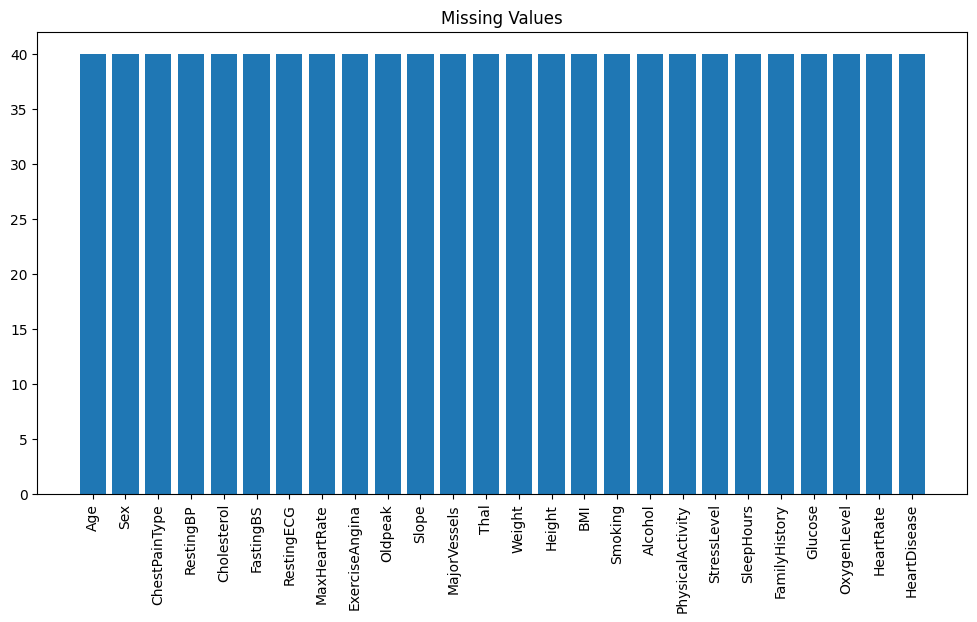

In [99]:
missing = heart_df.isnull().sum()

plt.figure(figsize=(12,6))

plt.bar(
    missing.index,
    missing.values
)

plt.xticks(rotation=90)

plt.title('Missing Values')

plt.show()

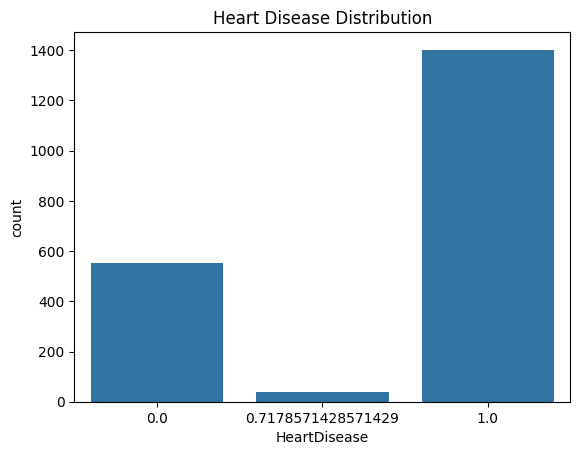

In [100]:
sns.countplot(
    x='HeartDisease',
    data=clean_df
)

plt.title('Heart Disease Distribution')

plt.show()

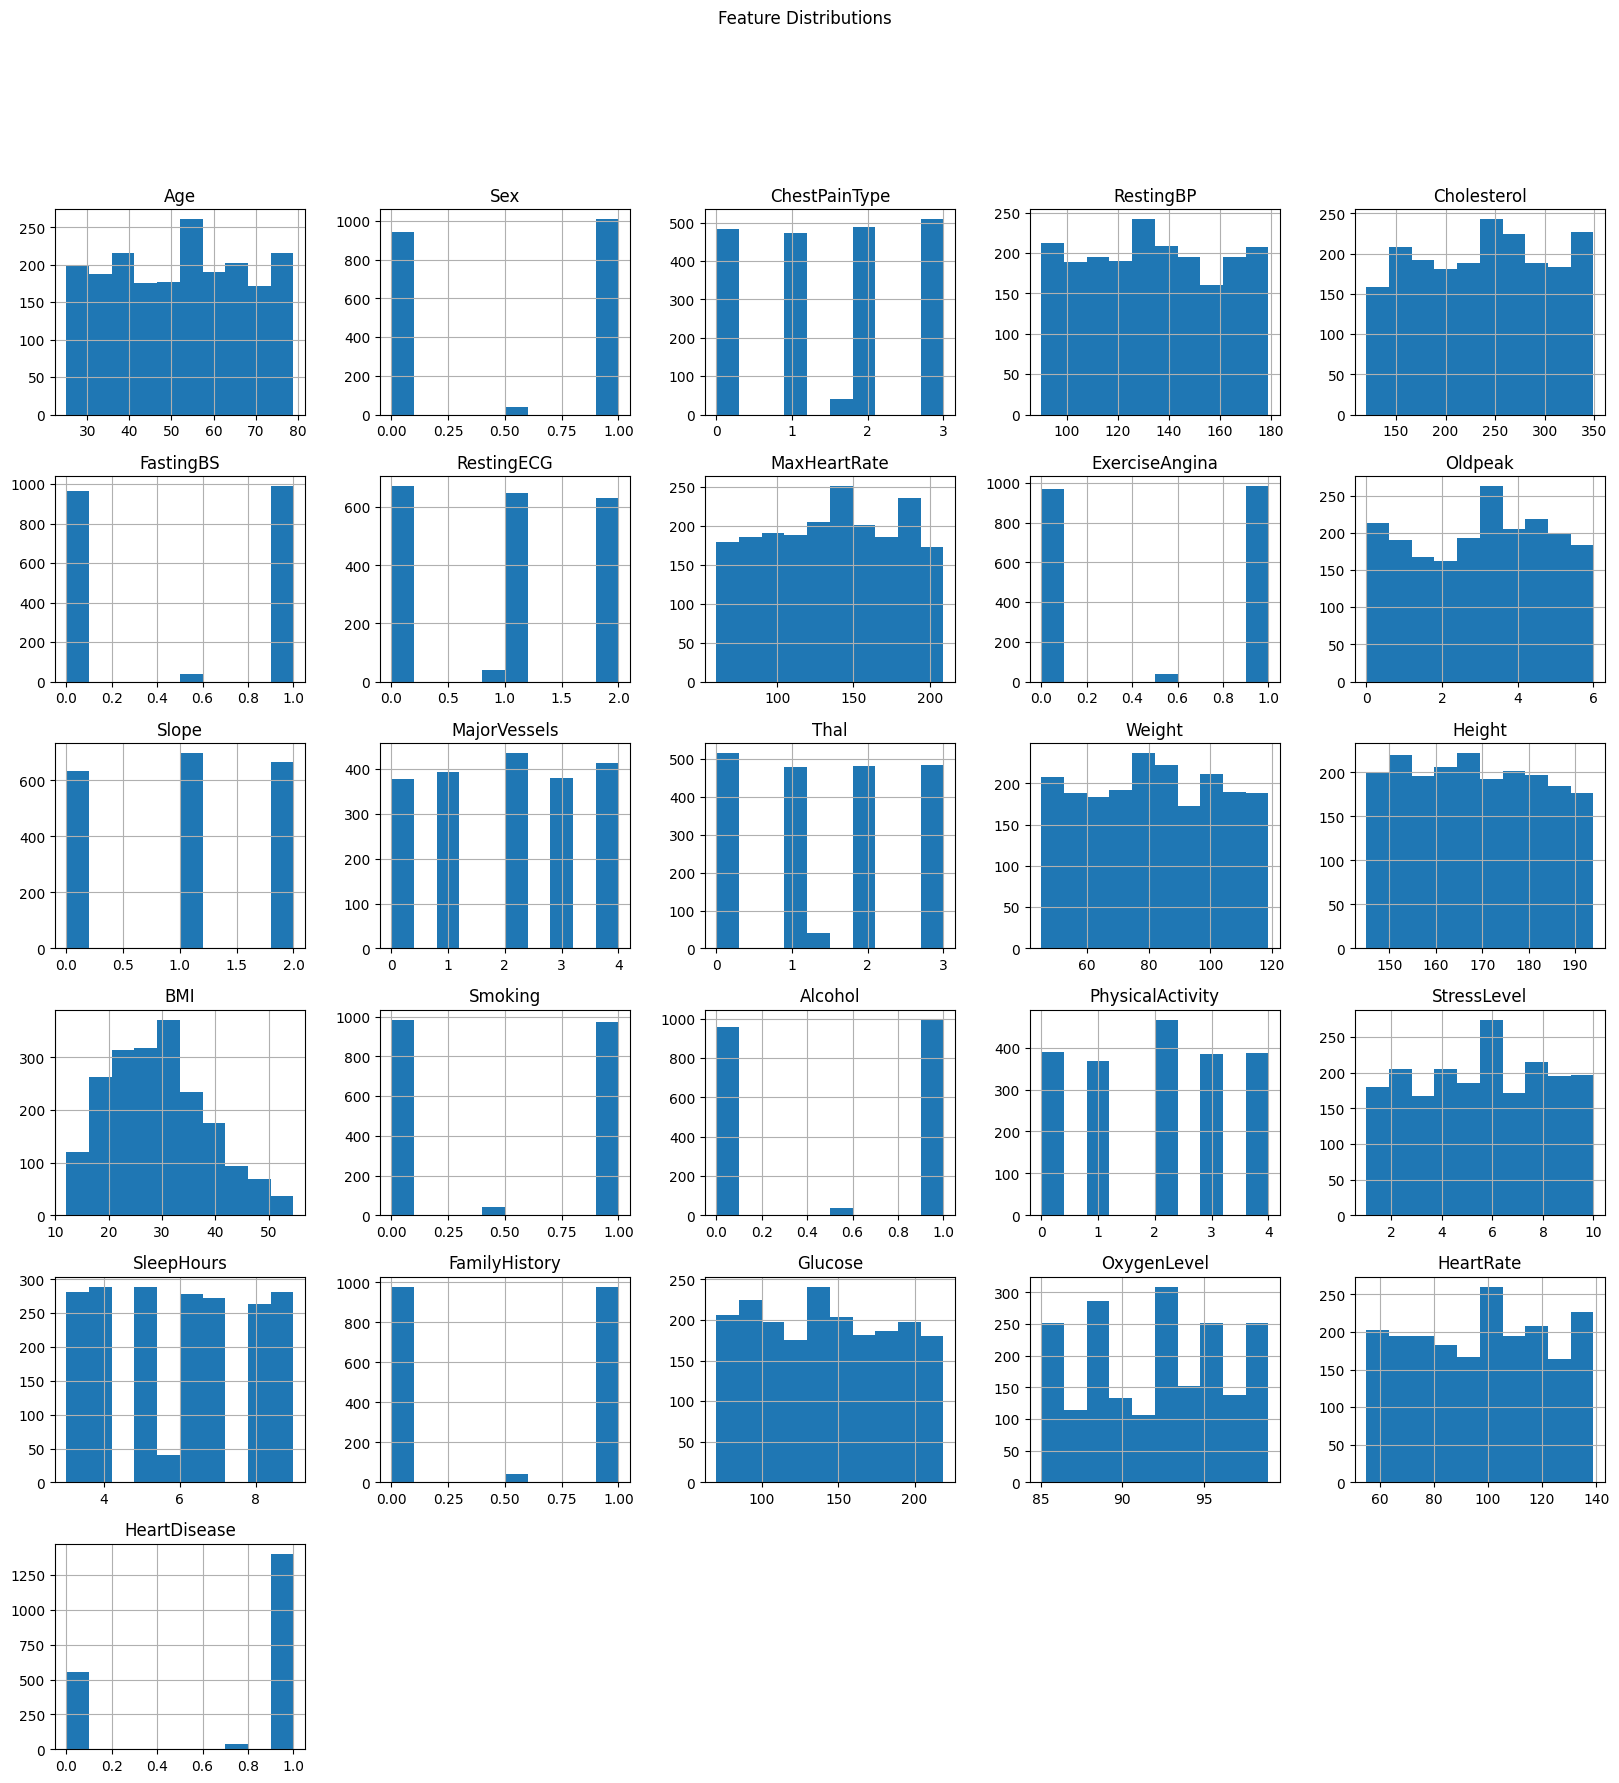

In [101]:
clean_df.hist(figsize=(20,20))

plt.suptitle('Feature Distributions')

plt.show()

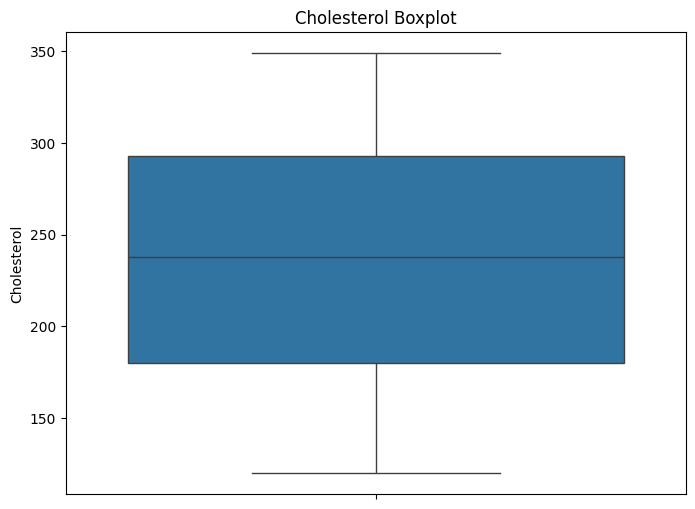

In [102]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=clean_df['Cholesterol']
)

plt.title('Cholesterol Boxplot')

plt.show()

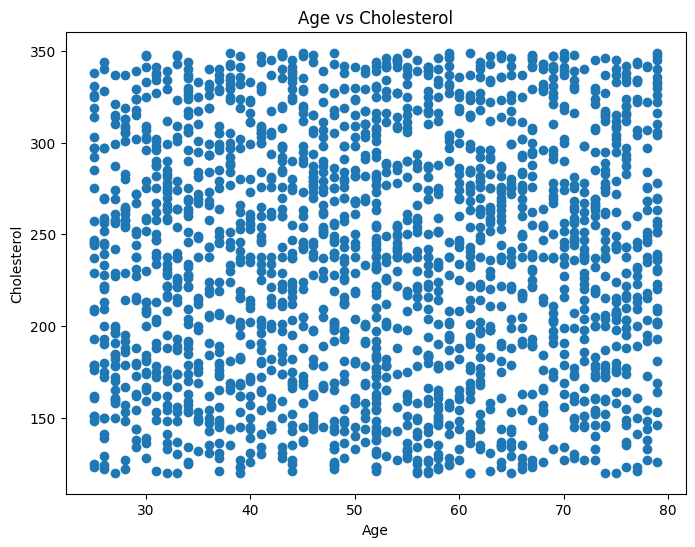

In [103]:
plt.figure(figsize=(8,6))

plt.scatter(
    clean_df['Age'],
    clean_df['Cholesterol']
)

plt.xlabel('Age')

plt.ylabel('Cholesterol')

plt.title('Age vs Cholesterol')

plt.show()

In [104]:
correlation = clean_df.corr()

print(correlation)

                       Age       Sex  ChestPainType  RestingBP  Cholesterol  \
Age               1.000000 -0.025876       0.029208  -0.018325     0.031264   
Sex              -0.025876  1.000000      -0.021276  -0.000353    -0.012778   
ChestPainType     0.029208 -0.021276       1.000000   0.059518    -0.017746   
RestingBP        -0.018325 -0.000353       0.059518   1.000000     0.000352   
Cholesterol       0.031264 -0.012778      -0.017746   0.000352     1.000000   
FastingBS        -0.019951 -0.025020       0.048517  -0.028820     0.021609   
RestingECG       -0.034856  0.030796      -0.003319   0.017677    -0.024483   
MaxHeartRate      0.008074  0.000035      -0.006330   0.014386     0.043441   
ExerciseAngina    0.002337  0.002927      -0.010405  -0.002625     0.048595   
Oldpeak           0.004207  0.023558      -0.028824   0.006548     0.005476   
Slope             0.007269  0.029567       0.029544  -0.004629    -0.032768   
MajorVessels     -0.011063  0.013444      -0.006602 

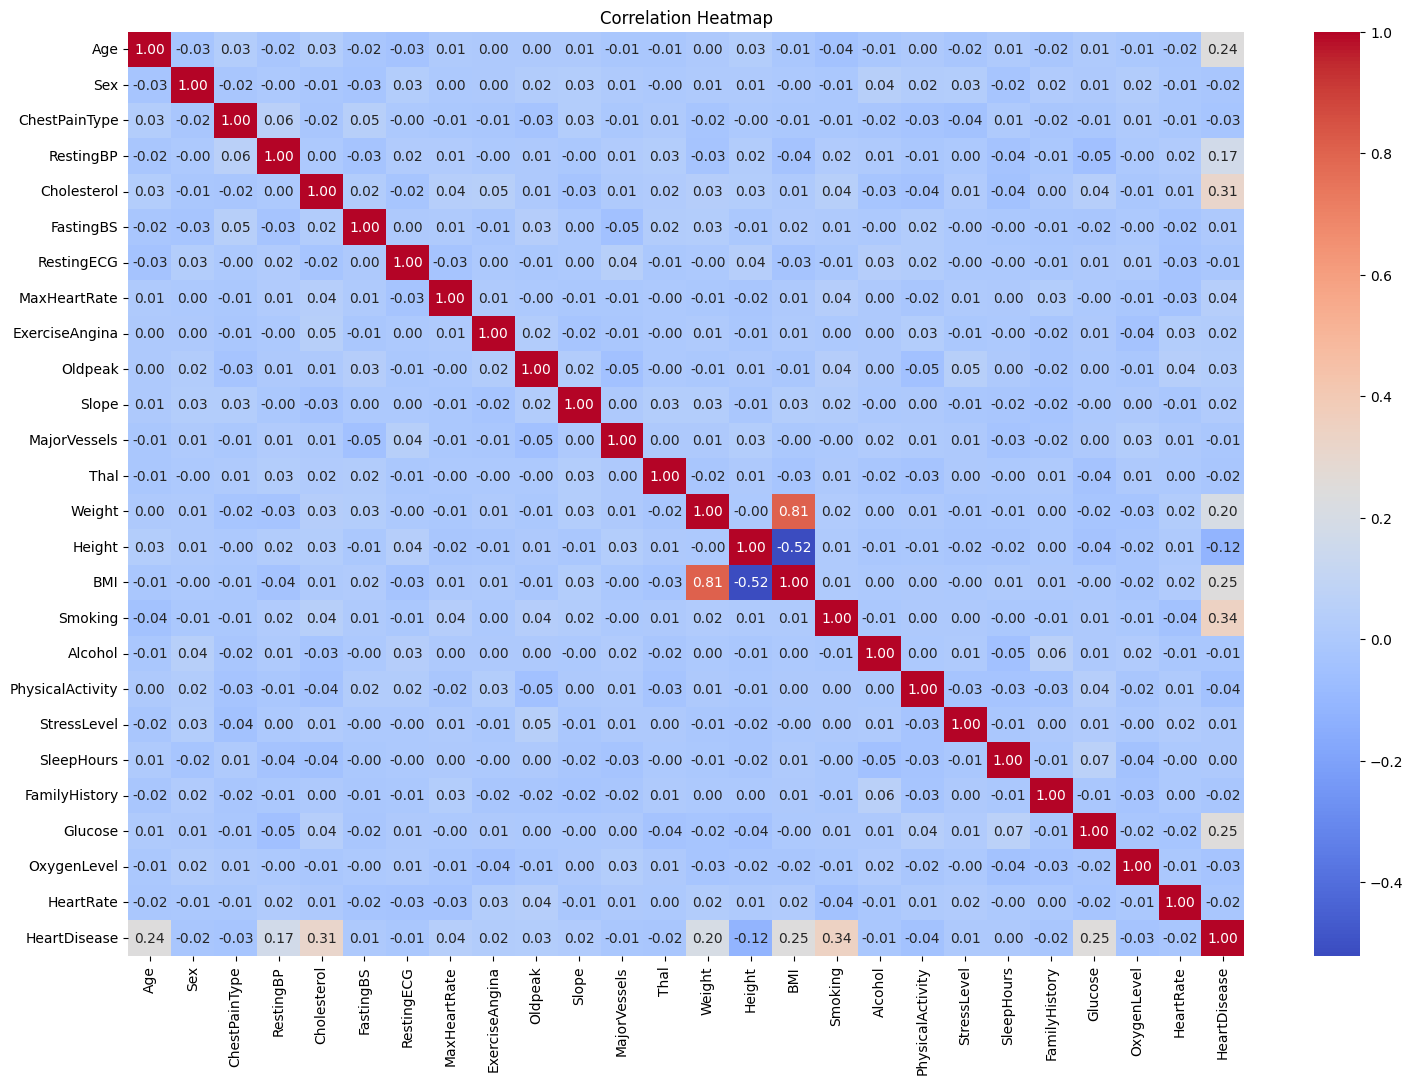

In [105]:
plt.figure(figsize=(18,12))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [106]:
important_features = clean_df[[
    'Age',
    'RestingBP',
    'Cholesterol',
    'BMI',
    'HeartDisease'
]]


In [107]:
print(
    correlation['HeartDisease']
    .sort_values(ascending=False)
)

HeartDisease        1.000000
Smoking             0.344944
Cholesterol         0.312653
Glucose             0.247592
BMI                 0.245253
Age                 0.242277
Weight              0.202052
RestingBP           0.173248
MaxHeartRate        0.039444
Oldpeak             0.027354
ExerciseAngina      0.024422
Slope               0.018667
FastingBS           0.007168
StressLevel         0.006894
SleepHours          0.002718
MajorVessels       -0.010831
Alcohol            -0.011444
RestingECG         -0.011812
Sex                -0.016175
Thal               -0.016540
HeartRate          -0.017481
FamilyHistory      -0.017992
ChestPainType      -0.027464
OxygenLevel        -0.031492
PhysicalActivity   -0.041568
Height             -0.118839
Name: HeartDisease, dtype: float64


In [108]:
clean_df['HeartDisease'] = clean_df['HeartDisease'].round()

clean_df['HeartDisease'] = clean_df['HeartDisease'].astype(int)

print(clean_df['HeartDisease'].unique())

[0 1]


In [109]:
X = clean_df.drop('HeartDisease', axis=1)

y = clean_df['HeartDisease']

In [110]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [111]:
minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

log_pred = log_model.predict(X_test)

In [114]:
print("LOGISTIC REGRESSION RESULTS")

print(
    "Accuracy:",
    accuracy_score(y_test, log_pred)
)

print(
    "Precision:",
    precision_score(y_test, log_pred)
)

print(
    "Recall:",
    recall_score(y_test, log_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, log_pred)
)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8621553884711779
Precision: 0.8903225806451613
Recall: 0.9292929292929293
F1 Score: 0.9093904448105437


In [115]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train,
    y_train
)

knn_pred = knn_model.predict(X_test)

In [116]:
print("KNN RESULTS")

print(
    "Accuracy:",
    accuracy_score(y_test, knn_pred)
)

print(
    "Precision:",
    precision_score(y_test, knn_pred)
)

print(
    "Recall:",
    recall_score(y_test, knn_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, knn_pred)
)

KNN RESULTS
Accuracy: 0.7994987468671679
Precision: 0.8604651162790697
Recall: 0.8720538720538721
F1 Score: 0.8662207357859532


<function matplotlib.pyplot.show(close=None, block=None)>

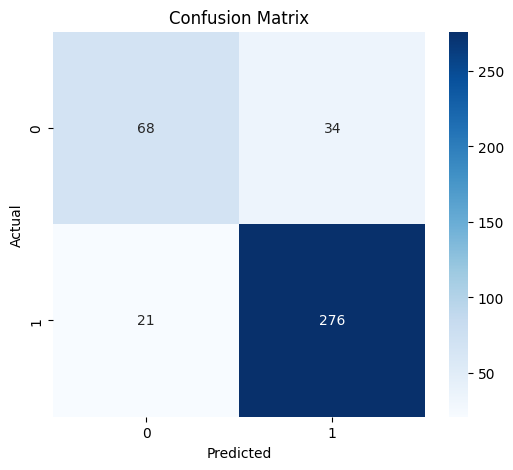

In [117]:
cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show

In [118]:
print(
    classification_report(
        y_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.76      0.67      0.71       102
           1       0.89      0.93      0.91       297

    accuracy                           0.86       399
   macro avg       0.83      0.80      0.81       399
weighted avg       0.86      0.86      0.86       399



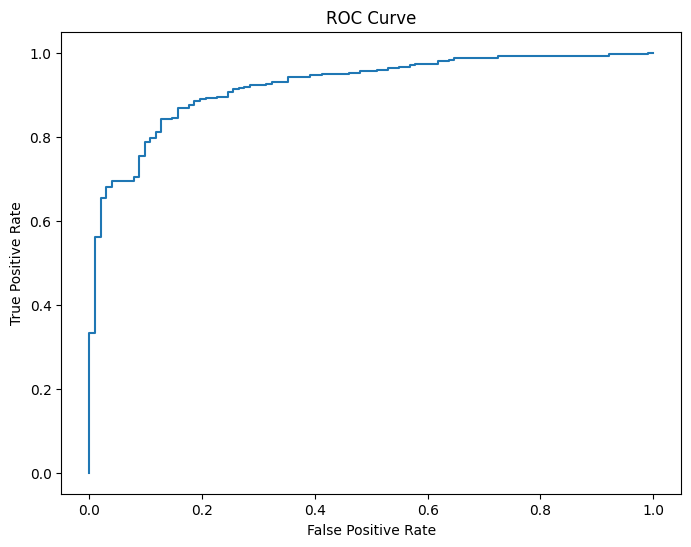

AUC Score: 0.9214365881032548


In [119]:
log_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    log_prob
)

auc_score = roc_auc_score(
    y_test,
    log_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

print("AUC Score:", auc_score)

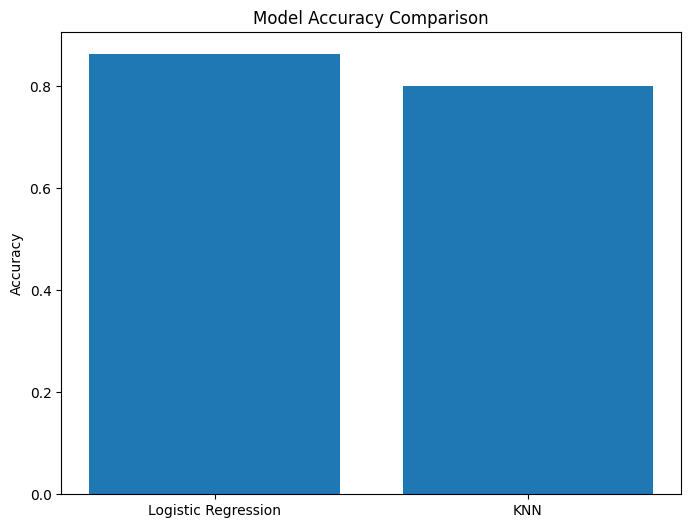

In [120]:
models = [
    'Logistic Regression',
    'KNN'
]

accuracies = [
    accuracy_score(y_test, log_pred),
    accuracy_score(y_test, knn_pred)
]

plt.figure(figsize=(8,6))

plt.bar(models, accuracies)

plt.ylabel('Accuracy')

plt.title('Model Accuracy Comparison')

plt.show()

In [121]:

# FINAL PREDICTION USING LOGISTIC REGRESSION AND KNN

new_patient = [[
    58,     # Age
    1,      # Sex
    2,      # ChestPainType
    150,    # RestingBP
    260,    # Cholesterol
    1,      # FastingBS
    1,      # RestingECG
    120,    # MaxHeartRate
    1,      # ExerciseAngina
    2.5,    # Oldpeak
    1,      # Slope
    2,      # MajorVessels
    2,      # Thal
    85,     # Weight
    170,    # Height
    29.4,   # BMI
    1,      # Smoking
    0,      # Alcohol
    1,      # PhysicalActivity
    8,      # StressLevel
    5,      # SleepHours
    1,      # FamilyHistory
    180,    # Glucose
    89,     # OxygenLevel
    110     # HeartRate
]]

new_patient_df = pd.DataFrame(
    new_patient,
    columns=X.columns
)

new_patient_scaled = standard_scaler.transform(
    new_patient_df
)

# LOGISTIC REGRESSION PREDICTION

log_prediction = log_model.predict(
    new_patient_scaled
)
if log_prediction[0] == 1:
    print(
        "Logistic Regression Prediction : Patient has Heart Disease"
    )
else:
    print(
        "Logistic Regression Prediction : Patient does NOT have Heart Disease"
    )

# KNN PREDICTION


knn_prediction = knn_model.predict(
    new_patient_scaled
)
if knn_prediction[0] == 1:
    print(
        "KNN Prediction : Patient has Heart Disease"
    )
else:
    print(
        "KNN Prediction : Patient does NOT have Heart Disease"
    )

Logistic Regression Prediction : Patient has Heart Disease
KNN Prediction : Patient has Heart Disease
